In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from collections import OrderedDict
from models import NonlinearNet

# --- Config ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.set_default_dtype(torch.float32)

# Directory corretta per i risultati di Leno
output_dir = 'results_leno'

def main_test():
    # --- 1. LOAD CONFIGURATION ---
    config_path = os.path.join(output_dir, 'config_model.json')
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Model config not found at {config_path}. Run train_leno.py first!")

    with open(config_path, 'r') as f:
        config = json.load(f)

    # --- LOAD TEST DATA ---
    # I dati di test rimangono nella cartella 'data/'
    print("Loading test data...")
    if not os.path.exists('data/data_ac_graph_test.npy'):
        raise FileNotFoundError("Test data not found in data/ folder!")
        
    sol_np = np.load('data/data_ac_graph_test.npy') 
    graph_info = np.load('data/graph_info.npz')

    eigenvalues_np = graph_info['eigenvalues']
    eigenvectors_np = graph_info['eigenvectors']

    # --- CONFIG SETUP ---
    dt = config["DT"]
    true_epsilon = config["EPSILON"] 
    # FIX: Il vero parametro fisico è D = epsilon^2
    true_D = true_epsilon**2
    
    p = config["p"]
    M = config["M"]
    learn_D_mode = config.get("learn_D", False)

    real_time_steps = sol_np.shape[1] - 1 
    config_steps = config["NUM_STEPS"]
    num_steps = min(real_time_steps, config_steps)

    print(f"Test Configuration: Steps={num_steps}, p={p}, M={M}")
    print(f"Mode: {'SYSTEM IDENTIFICATION (Learn D)' if learn_D_mode else 'STANDARD (Fixed D)'}")

    # --- DATA PREP ---
    Phi = torch.tensor(eigenvectors_np, dtype=torch.float32).to(device)
    Phi_p = Phi[:, :p]
    sol = torch.tensor(sol_np, dtype=torch.float32).to(device)
    eigen = torch.tensor(eigenvalues_np[:p], dtype=torch.float32).to(device)

    # Project TEST data to spectral space
    myall = torch.matmul(sol, Phi_p) 
    initial = myall[:, 0, :]
    
    # --- LOAD NET & PARAMETERS ---
    net = NonlinearNet(M, p).to(device)
    used_D = true_D # Default fallback

    model_path = os.path.join(output_dir, 'leno_model_graph.pth')

    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
            
            # --- LOGICA DI SELEZIONE D ---
            if learn_D_mode:
                if 'epsilon' in checkpoint:
                    learned_eps = checkpoint['epsilon']
                    # FIX: Converto subito in D per coerenza fisica
                    learned_D = learned_eps**2 
                    used_D = learned_D
                    
                    err_perc = abs(learned_D - true_D)/true_D * 100
                    print(f"\n[INFO] Using LEARNED parameter from checkpoint.")
                    print(f"       Learned D : {learned_D:.6f}")
                    print(f"       True D    : {true_D:.6f}")
                    print(f"       Error     : {err_perc:.2f}%\n")
                else:
                    print("\n[WARNING] Config learn_D=True, but 'epsilon' missing. Using GT.")
            else:
                print(f"\n[INFO] Using FIXED Ground Truth D.")
                
        else:
            state_dict = checkpoint

        # Carica pesi (Rimuove prefisso _orig_mod dovuto a torch.compile)
        clean_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k.replace("_orig_mod.", "") 
            clean_state_dict[name] = v
        net.load_state_dict(clean_state_dict)
    else:
        raise FileNotFoundError(f"Model file not found at {model_path}!")

    net.eval()

    # --- PREDICTION LOOP ---
    with torch.no_grad():
        u0 = initial
        loss_traj = 0
        pred_spectral = [u0]
        
        # Uso D direttamente (già quadrato)
        denom = (1 + used_D * dt * eigen)
        
        for step in range(num_steps):
            u = (u0 + dt * net(u0)) / denom
            pred_spectral.append(u)
            
            u_phys_pred = torch.matmul(u, Phi_p.T)
            u_phys_true = sol[:, step+1, :] 
            norm_diff = torch.norm(u_phys_pred - u_phys_true, p=2, dim=-1)
            norm_true = torch.norm(u_phys_true, p=2, dim=-1)
            loss_traj += torch.mean(norm_diff / (norm_true + 1e-6))
            u0 = u

        loss_traj /= num_steps
        pred_spectral = torch.stack(pred_spectral, dim=1)

        print("-" * 50)
        print(f"TEST SET RESULTS (Avg over {num_steps} steps):")
        print("Relative L2 Error: {:2.4%}".format(loss_traj.item()))
        print("-" * 50)
        
        # Ricostruzione fisica per plot esterni
        u_pred_phys = torch.matmul(pred_spectral, Phi_p.T).cpu().numpy()
        u_true_phys = sol[:, :num_steps+1, :].cpu().numpy()
        
        return u_pred_phys, u_true_phys

if __name__ == "__main__":
    u_pred_phys, u_true_phys = main_test()

Using device: cuda:0
Loading test data...
Test Configuration: Steps=20, p=1000, M=700
Mode: SYSTEM IDENTIFICATION (Learn D)


/tmp/ipykernel_4133086/2301112284.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)



[INFO] Using LEARNED parameter from checkpoint.
       Learned D : 3.526440
       True D    : 4.000000
       Error     : 11.84%

--------------------------------------------------
TEST SET RESULTS (Avg over 20 steps):
Relative L2 Error: 1.9630%
--------------------------------------------------


Visualizing Sample Index: 10
Data Min: -0.0001 -> Colorbar Range: [-0.10000000149011612, 1.0]


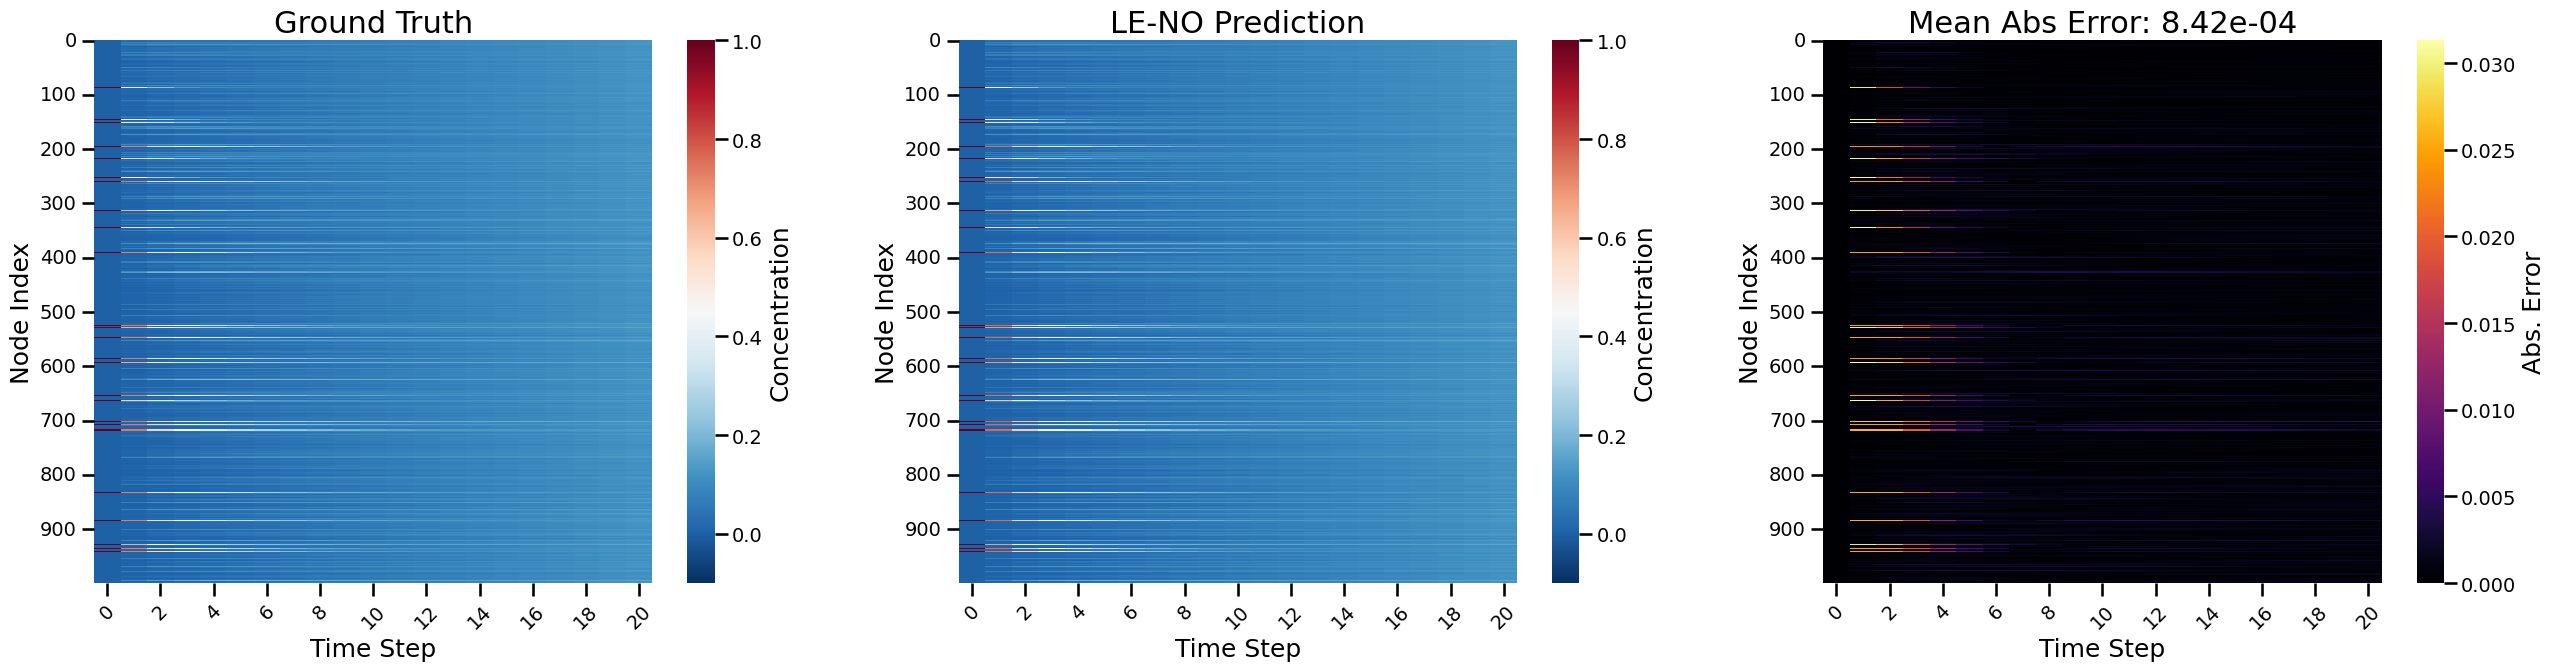

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- CONFIGURAZIONE STILE (GOLD STANDARD) ---
sns.set_context("talk", font_scale=1.1)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.titlesize': 26
})

def get_nice_min(value):
    """Arrotonda il minimo al decimo inferiore per pulizia."""
    return np.floor(value * 10) / 10.0

# Selezioniamo un indice
sample_idx = 10 
print(f"Visualizing Sample Index: {sample_idx}")

# Estrazione dati (LE-NO: numpy arrays)
u_true_map = u_true_phys[sample_idx].T
u_pred_map = u_pred_phys[sample_idx].T
u_err_map = np.abs(u_true_map - u_pred_map)

# --- CALCOLO PASSO PER GLI ASSI ---
num_nodes = u_true_map.shape[0]
num_time = u_true_map.shape[1]
y_step = max(1, num_nodes // 10) 
x_step = max(1, num_time // 10)

# --- LOGICA COLORI ---
# 1. Minimo Dinamico Arrotondato
global_min = min(u_true_map.min(), u_pred_map.min())
vmin = get_nice_min(global_min)

# 2. Massimo Fisso
vmax = 1.0

print(f"Data Min: {global_min:.4f} -> Colorbar Range: [{vmin}, {vmax}]")

# Setup grafico
fig, axes = plt.subplots(1, 3, figsize=(26, 7))

# Helper per parametri comuni
heatmap_args = {
    'vmin': vmin, 'vmax': vmax, 
    'cmap': 'RdBu_r', 
    'cbar': True,
    'xticklabels': x_step,
    'yticklabels': y_step
}

# 1. Ground Truth
sns.heatmap(u_true_map, ax=axes[0], cbar_kws={'label': 'Concentration'}, **heatmap_args)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Node Index')

# 2. Prediction
sns.heatmap(u_pred_map, ax=axes[1], cbar_kws={'label': 'Concentration'}, **heatmap_args)
axes[1].set_title('LE-NO Prediction') 
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Node Index')

# 3. Absolute Error
mae = np.mean(u_err_map)
sns.heatmap(u_err_map, ax=axes[2], cmap='inferno', vmin=0, 
            xticklabels=x_step, yticklabels=y_step,
            cbar=True, cbar_kws={'label': 'Abs. Error'})

# FORMATTAZIONE SCIENTIFICA NEL TITOLO
axes[2].set_title(f'Mean Abs Error: {mae:.2e}') 
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Node Index')

# Rotazione tick
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout(w_pad=3.0) 
plt.show()

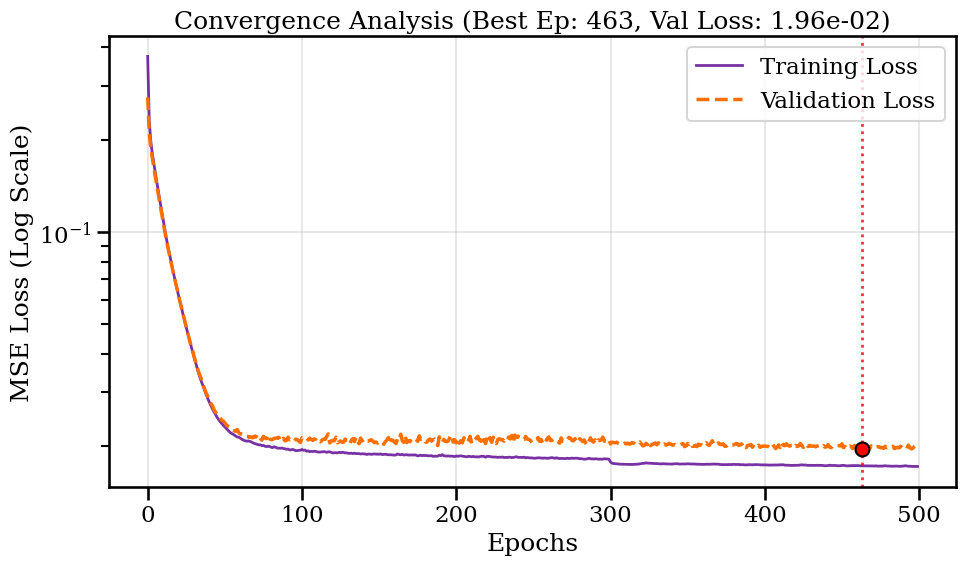

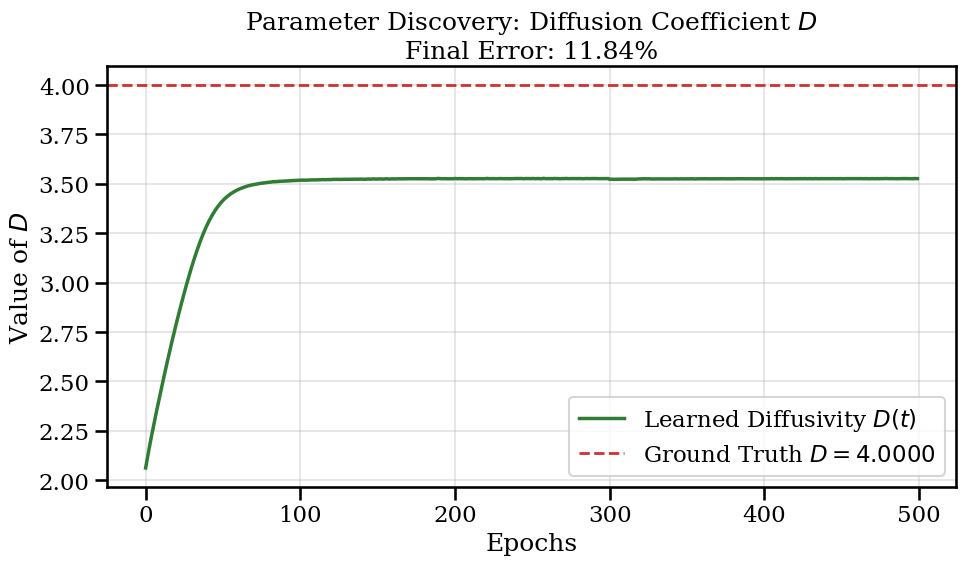

Final Identified D: 3.526506
Ground Truth D    : 4.000000


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import json

# --- CONFIGURAZIONE STILE REPORT ---
sns.set_context("talk")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Cartella corretta
output_dir = 'results_leno'

# --- 1. PLOT TRAINING DYNAMICS (LOSS) ---
loss_path = os.path.join(output_dir, 'loss_history.npy')
val_loss_path = os.path.join(output_dir, 'val_loss_history.npy')

plt.figure(figsize=(10, 6))

# Caricamento Training Loss
if os.path.exists(loss_path):
    train_loss = np.load(loss_path)
    plt.plot(train_loss, label='Training Loss', color='#6A1B9A', linewidth=2, alpha=0.9) # Purple
else:
    print(f"⚠️ Training loss file not found in {loss_path}")
    train_loss = []

# Caricamento Validation Loss & Best Epoch
if os.path.exists(val_loss_path):
    val_loss = np.load(val_loss_path)
    plt.plot(val_loss, label='Validation Loss', color='#FF6F00', linewidth=2.5, linestyle='--') # Amber
    
    # Trova il minimo (Best Model)
    best_epoch_idx = np.argmin(val_loss)
    min_val_loss = val_loss[best_epoch_idx]
    
    plt.axvline(x=best_epoch_idx, color='red', linestyle=':', linewidth=2, alpha=0.8)
    plt.scatter(best_epoch_idx, min_val_loss, color='red', s=100, zorder=5, edgecolors='black')
    
    # Annotazione spostata per leggibilità
    plt.title(f'Convergence Analysis (Best Ep: {best_epoch_idx}, Val Loss: {min_val_loss:.2e})')
else:
    plt.title('Convergence Analysis: Training Only')

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Log Scale)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --- 2. PLOT SYSTEM IDENTIFICATION (DIFFUSION D) ---
eps_path = os.path.join(output_dir, 'epsilon_history.npy')

if os.path.exists(eps_path):
    # Carica Config per Ground Truth (Originale in data/)
    true_D = None
    if os.path.exists('data/config_data.json'):
        with open('data/config_data.json') as f:
            config = json.load(f)
            true_D = config["EPSILON"]**2 # D = epsilon^2
    
    # Carica e converti History
    eps_hist = np.load(eps_path)
    D_hist = eps_hist ** 2 # Conversione fisica
    
    plt.figure(figsize=(10, 6))
    plt.plot(D_hist, label=r'Learned Diffusivity $D(t)$', color='#2E7D32', linewidth=2.5) # Green
    
    if true_D is not None:
        plt.axhline(y=true_D, color='#D32F2F', linestyle='--', linewidth=2, label=f'Ground Truth $D={true_D:.4f}$')
        
        final_D = D_hist[-1]
        err_perc = abs(final_D - true_D)/true_D * 100
        title_str = f'Parameter Discovery: Diffusion Coefficient $D$\nFinal Error: {err_perc:.2f}%'
    else:
        title_str = 'Parameter Discovery: Diffusion Coefficient $D$'

    plt.title(title_str)
    plt.xlabel('Epochs')
    plt.ylabel(r'Value of $D$')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    if true_D:
        print(f"Final Identified D: {D_hist[-1]:.6f}")
        print(f"Ground Truth D    : {true_D:.6f}")
else:
    print(f"ℹ️ Epsilon history not found in {eps_path} (Fixed D mode?).")

## Istogramma errore

METRIC               | MEAN       | STD DEV   
----------------------------------------------
Absolute L2 Error    | 0.35762    | 0.01983
Relative L2 Error    | 0.02279    | 0.00121
----------------------------------------------


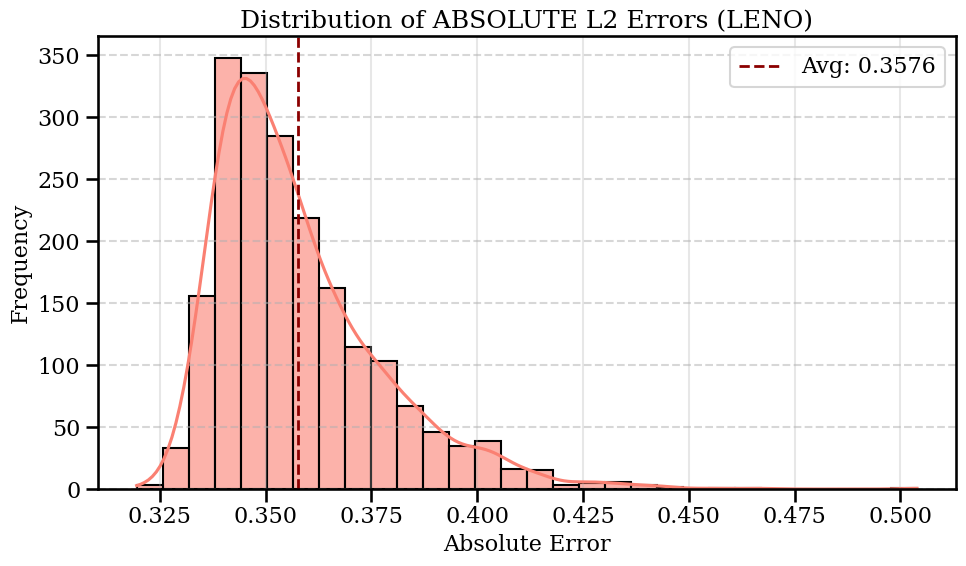

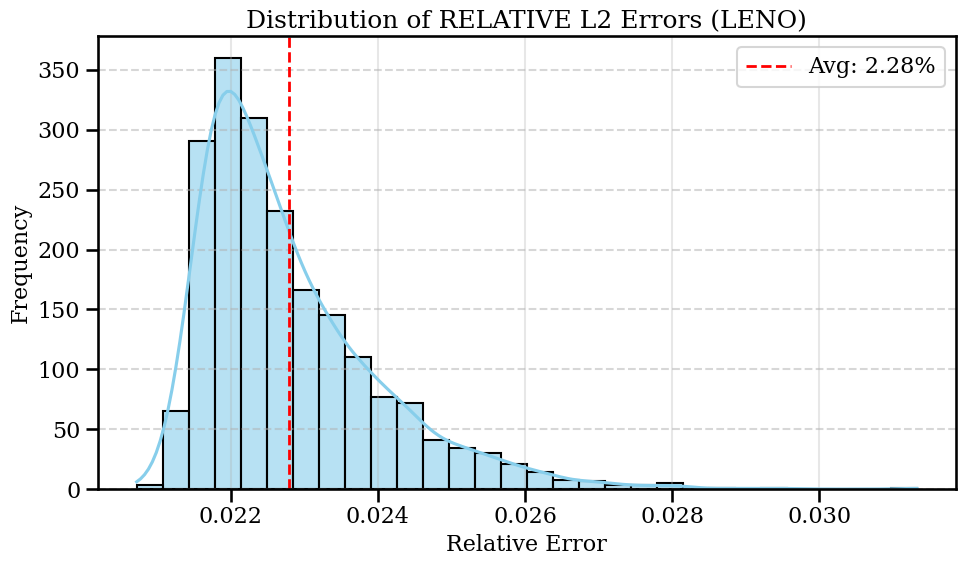

In [8]:
# --- NUOVA CELLA: Istogrammi Errori (Separati - High Visibility) ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Verifica che i dati esistano
if 'u_pred_phys' not in locals() or 'u_true_phys' not in locals():
    raise NameError("Devi eseguire la cella precedente 'main_test()' per generare i dati!")

# 1. Reshape: (Batch, Time, Nodes) -> (Batch, Time * Nodes)
flat_pred = u_pred_phys.reshape(u_pred_phys.shape[0], -1)
flat_true = u_true_phys.reshape(u_true_phys.shape[0], -1)

# 2. Calcoli
# Errore Assoluto: || u_pred - u_true ||_2
abs_errors = np.linalg.norm(flat_pred - flat_true, axis=1)

# Norma del target: || u_true ||_2
true_norms = np.linalg.norm(flat_true, axis=1)

# Errore Relativo: || u_pred - u_true ||_2 / || u_true ||_2
rel_errors = abs_errors / (true_norms + 1e-6)

# 3. Statistiche
mean_abs = np.mean(abs_errors)
std_abs = np.std(abs_errors)
mean_rel = np.mean(rel_errors)
std_rel = np.std(rel_errors)

print(f"{'METRIC':<20} | {'MEAN':<10} | {'STD DEV':<10}")
print("-" * 46)
print(f"{'Absolute L2 Error':<20} | {mean_abs:.5f}    | {std_abs:.5f}")
print(f"{'Relative L2 Error':<20} | {mean_rel:.5f}    | {std_rel:.5f}")
print("-" * 46)

# --- PLOT 1: Absolute Error ---
plt.figure(figsize=(10, 6))
sns.histplot(abs_errors, bins=30, kde=True, color='salmon', edgecolor='black', alpha=0.6)
plt.axvline(mean_abs, color='darkred', linestyle='--', linewidth=2, label=f'Avg: {mean_abs:.4f}')

plt.title('Distribution of ABSOLUTE L2 Errors (LENO)')
plt.xlabel('Absolute Error', fontsize=16)     
plt.ylabel('Frequency', fontsize=16)          
plt.legend(fontsize=16)                       
plt.tick_params(axis='both', which='major', labelsize=16) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show() 

# --- PLOT 2: Relative Error ---
plt.figure(figsize=(10, 6))
sns.histplot(rel_errors, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.6)
plt.axvline(mean_rel, color='red', linestyle='--', linewidth=2, label=f'Avg: {mean_rel:.2%}')

plt.title('Distribution of RELATIVE L2 Errors (LENO)')
plt.xlabel('Relative Error', fontsize=16)     
plt.ylabel('Frequency', fontsize=16)          
plt.legend(fontsize=16)                       
plt.tick_params(axis='both', which='major', labelsize=16) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Zoom Results

## Visualizzazione dinamica simulata

Loading configuration...
Loading dataset...


/tmp/ipykernel_4133086/4111306932.py:92: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


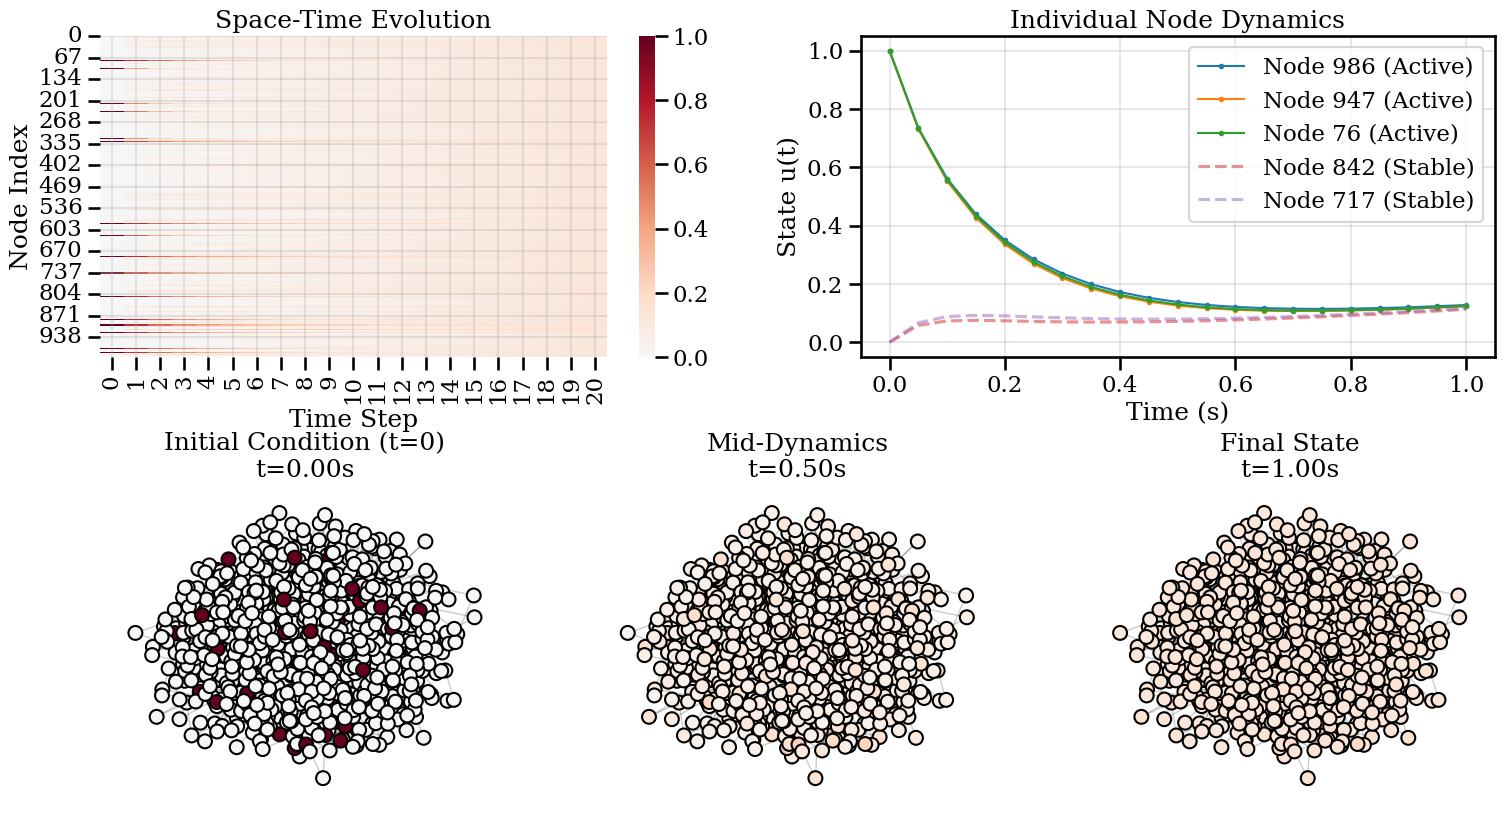

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import os
import json

# --- 1. Load Configuration & Data ---
print("Loading configuration...")
if not os.path.exists('data/config_data.json'):
    raise FileNotFoundError("Config file not found. Run generate_data.py first!")

with open('data/config_data.json', 'r') as f:
    config = json.load(f)

dt = config["DT"]
num_steps = config["NUM_STEPS"]

print("Loading dataset...")
# Carichiamo il dataset di TRAINING per visualizzare le simulazioni generate
data_file = 'data/data_ac_graph_train.npy' 

if not os.path.exists(data_file):
    raise FileNotFoundError(f"{data_file} not found. Run generate_data.py first!")

data = np.load(data_file)  # Shape: (N_samples, Time, Nodes)
graph_info = np.load('data/graph_info.npz')
L = graph_info['L']  # Laplacian Matrix

# Select a sample to visualize (e.g., the first one)
sample_idx = 0
trajectory = data[sample_idx]  # Shape: (Time, Nodes)
steps_in_traj, num_nodes = trajectory.shape

# Create time axis based on config
time_axis = np.linspace(0, (steps_in_traj-1) * dt, steps_in_traj)

# --- 2. Reconstruct Graph for Visualization ---
# We reconstruct the graph topology from the Laplacian matrix.
adj_matrix = np.where(L < 0, 1, 0) 
G = nx.from_numpy_array(adj_matrix)

# Pre-compute layout for consistent node positioning
pos = nx.spring_layout(G, seed=42) 

# --- Visualization ---
fig = plt.figure(figsize=(18, 10))

# A. Space-Time Heatmap
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(trajectory.T, ax=ax1, cmap='RdBu_r', center=0, cbar=True)
ax1.set_title("Space-Time Evolution")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Node Index")

# B. Single Node Trajectories
ax2 = plt.subplot(2, 2, 2)
variances = np.var(trajectory, axis=0)
active_nodes = np.argsort(variances)[-3:] # Top 3 active
stable_nodes = np.argsort(variances)[:2]  # Top 2 stable

for node in active_nodes:
    ax2.plot(time_axis, trajectory[:, node], 'o-', label=f'Node {node} (Active)', linewidth=1.5, markersize=3)

for node in stable_nodes:
    ax2.plot(time_axis, trajectory[:, node], '--', label=f'Node {node} (Stable)', alpha=0.5)

ax2.set_title("Individual Node Dynamics")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("State u(t)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# C. Graph Snapshots (Start, Middle, End)
times_to_plot_indices = [0, steps_in_traj // 2, steps_in_traj - 1]
titles = ["Initial Condition (t=0)", "Mid-Dynamics", "Final State"]

for i, t_idx in enumerate(times_to_plot_indices):
    ax = plt.subplot(2, 3, 4 + i) # Positions 4, 5, 6
    
    node_colors = trajectory[t_idx, :]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=100, 
                           node_color=node_colors, cmap='RdBu_r', 
                           vmin=-1, vmax=1, edgecolors='k')
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2)
    
    real_time = t_idx * dt
    ax.set_title(f"{titles[i]}\nt={real_time:.2f}s")
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- MODIFICA AGGIUNTA ---
# Aumenta lo spazio verticale (height space) tra le righe di plot
plt.subplots_adjust(hspace=0.4) 
# -------------------------

plt.show()

## Zoom Results

Using device: cuda:0
Caricamento dati...
--> Using LEARNED Parameter D = 3.52644 (True: 4.00000)
Esecuzione predizione...


/tmp/ipykernel_4133086/1392927351.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


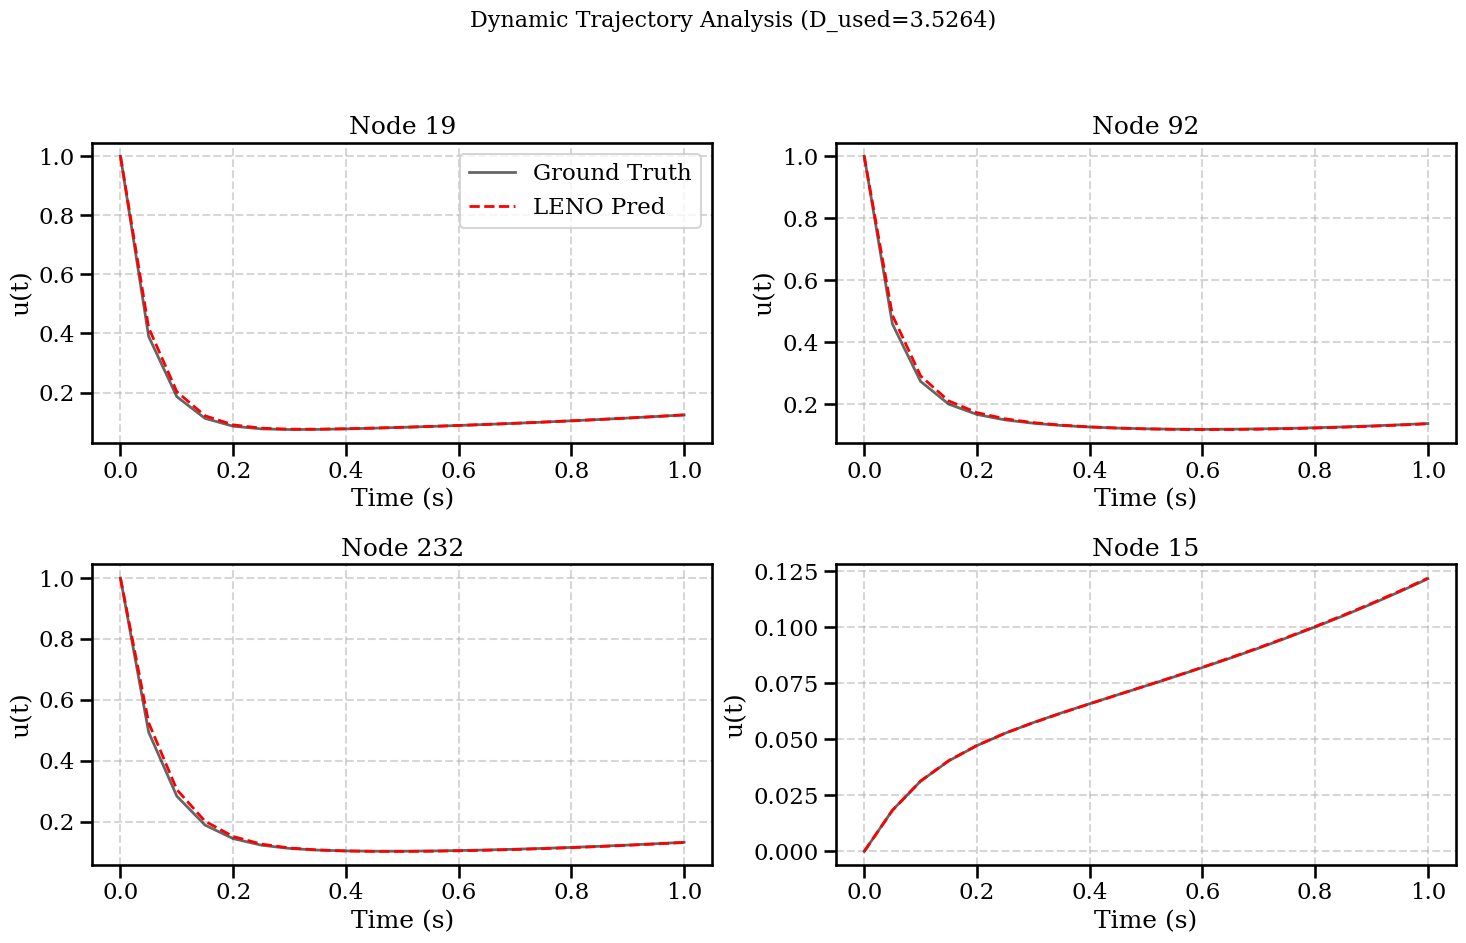

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from collections import OrderedDict
from models import NonlinearNet

# --- Configurazione ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.set_default_dtype(torch.float32)

# Directory corretta
output_dir = 'results_leno'

def main_plot_dynamics():
    # --- 1. CARICAMENTO CONFIGURAZIONE ---
    config_path = os.path.join(output_dir, 'config_model.json')
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Model config not found at {config_path}")

    with open(config_path, 'r') as f:
        config = json.load(f)

    # --- CARICAMENTO DATI (da DATA) ---
    print("Caricamento dati...")
    sol_np = np.load('data/data_ac_graph_test.npy') 
    graph_info = np.load('data/graph_info.npz')
    
    eigenvalues_np = graph_info['eigenvalues']
    eigenvectors_np = graph_info['eigenvectors']

    # Parametri
    dt = config["DT"]
    true_epsilon = config["EPSILON"]
    p = config["p"]
    M = config["M"]
    learn_D_mode = config.get("learn_D", False)
    
    # Determina numero passi
    real_time_steps = sol_np.shape[1] - 1 
    config_steps = config["NUM_STEPS"]
    num_steps = min(real_time_steps, config_steps)

    # --- 2. PREPARAZIONE TENSORI ---
    Phi = torch.tensor(eigenvectors_np, dtype=torch.float32).to(device)
    Phi_p = Phi[:, :p] 
    
    sol = torch.tensor(sol_np, dtype=torch.float32).to(device)
    eigen = torch.tensor(eigenvalues_np[:p], dtype=torch.float32).to(device)

    # Proiezione iniziale
    u0_spectral = torch.matmul(sol[:, 0, :], Phi_p) 
    
    # --- 3. CARICAMENTO MODELLO E PARAMETRO ---
    # Inizializza con M corretto dal config caricato
    net = NonlinearNet(M, p).to(device)
    used_epsilon = true_epsilon 

    model_path = os.path.join(output_dir, 'leno_model_graph.pth')

    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        
        # Gestione Checkpoint
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
            
            # SE IL MODELLO HA IMPARATO D, USIAMO QUELLO!
            if learn_D_mode and 'epsilon' in checkpoint:
                used_epsilon = checkpoint['epsilon']
                used_D = used_epsilon**2 # Conversione
                print(f"--> Using LEARNED Parameter D = {used_D:.5f} (True: {true_epsilon**2:.5f})")
            else:
                used_D = true_epsilon**2
                print(f"--> Using FIXED Parameter D = {used_D:.5f}")
        else:
            state_dict = checkpoint
            used_D = true_epsilon**2
            
        clean_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k.replace("_orig_mod.", "")
            clean_state_dict[name] = v
        net.load_state_dict(clean_state_dict)
    else:
        raise FileNotFoundError(f"Model file not found at {model_path}")
        
    net.eval()

    # --- 4. PREDIZIONE ---
    print("Esecuzione predizione...")
    pred_spectral = [u0_spectral]
    curr_u = u0_spectral
    
    # CRUCIALE: Usare 'used_D' qui
    denom = (1 + used_D * dt * eigen)

    with torch.no_grad():
        for step in range(num_steps):
            next_u = (curr_u + dt * net(curr_u)) / denom
            pred_spectral.append(next_u)
            curr_u = next_u

    pred_spectral = torch.stack(pred_spectral, dim=1)

    # --- 5. RICOSTRUZIONE SPAZIO FISICO ---
    u_pred_phys = torch.matmul(pred_spectral, Phi_p.T).cpu().numpy()
    u_true_phys = sol_np[:, :num_steps+1, :]
    
    # --- 6. PLOTTING ---
    sample_idx = 0 
    u0_values = u_true_phys[sample_idx, 0, :]
    sorted_indices = np.argsort(np.abs(u0_values))[::-1]
    
    nodes_to_plot = [sorted_indices[0], sorted_indices[5], sorted_indices[10], sorted_indices[-1]]

    time_axis = np.linspace(0, num_steps * dt, num_steps + 1)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Dynamic Trajectory Analysis (D_used={used_D:.4f})', fontsize=16)
    
    axes = axes.flatten()

    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        traj_true = u_true_phys[sample_idx, :, node_idx]
        traj_pred = u_pred_phys[sample_idx, :, node_idx]
        
        ax.plot(time_axis, traj_true, 'k-', label='Ground Truth', linewidth=2, alpha=0.6)
        ax.plot(time_axis, traj_pred, 'r--', label='LENO Pred', linewidth=2)
        
        ax.set_title(f"Node {node_idx}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("u(t)")
        ax.grid(True, linestyle='--', alpha=0.5)
        if i == 0: ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    main_plot_dynamics()